In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [4]:
# Load Dataset
df = pd.read_csv("/kaggle/input/datasets/lokeshhate/zomato-dataset/Dataset .csv")

In [5]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [6]:
df.shape

(9551, 21)

In [8]:
# Exploratory Data Analysis
df.isnull().sum()
df.describe(include="all")
df["Cuisines"].value_counts().head(20)

Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Pizza, Fast Food                  131
Chinese, Fast Food                118
Mithai, Street Food               116
South Indian                      112
Bakery, Fast Food                 108
Chinese, North Indian             105
Mughlai                           103
Ice Cream, Desserts                83
Ice Cream                          74
North Indian, Fast Food            74
Name: count, dtype: int64

In [9]:
#Data Cleaning
drop_cols = [
    "Restaurant ID",
    "Restaurant Name",
    "Address",
    "Locality",
    "Locality Verbose",
    "Longitude",
    "Latitude",
    "Rating color",
    "Rating text"
]

for col in drop_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

In [10]:
df.fillna("Unknown", inplace=True)

In [16]:
#Feature Engineering
df["Cuisine"] = df["Cuisine"].apply(lambda x: x.split(",")[0].strip())

In [17]:
df.columns

Index(['Country Code', 'City', 'Average Cost for two', 'Currency',
       'Has Table booking', 'Has Online delivery', 'Is delivering now',
       'Switch to order menu', 'Price range', 'Aggregate rating', 'Votes',
       'Cuisine'],
      dtype='object')

In [19]:
df.drop(columns=["Cuisines"], errors="ignore", inplace=True)

In [20]:
df["Cuisine"].value_counts().head(20)

Cuisine
North Indian    2992
Chinese          855
Fast Food        672
Bakery           621
Cafe             617
American         278
South Indian     262
Mithai           246
Street Food      236
Continental      235
Italian          234
Pizza            232
Mughlai          215
Ice Cream        178
Desserts         150
Burger           116
Biryani          112
Raw Meats        110
Beverages         79
Finger Food       78
Name: count, dtype: int64

In [22]:
# Prepare Features
y = df["Cuisine"]

In [23]:
X = df.drop("Cuisine",axis=1)

In [40]:
cat_cols = X.select_dtypes(include="object").columns

In [41]:
# Remove cuisines that appear only once
counts = df["Cuisine"].value_counts()

df = df[df["Cuisine"].isin(counts[counts >= 2].index)]

print(df.shape)

(9530, 12)


In [42]:
from sklearn.preprocessing import LabelEncoder

X = df.drop("Cuisine", axis=1)
y = df["Cuisine"]

# Encode categorical features
feature_encoder = LabelEncoder()

cat_cols = X.select_dtypes(include="object").columns

for col in cat_cols:
    X[col] = feature_encoder.fit_transform(X[col].astype(str))

# Encode target
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y)

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [49]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

In [50]:
print("Accuracy :",accuracy_score(y_test,pred_lr))
print("Precision :",precision_score(y_test,pred_lr,average="weighted"))
print("Recall :",recall_score(y_test,pred_lr,average="weighted"))
print("F1 :",f1_score(y_test,pred_lr,average="weighted"))

Accuracy : 0.3352570828961175
Precision : 0.138313379138988
Recall : 0.3352570828961175
F1 : 0.18088639218904118


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [51]:
print(classification_report(y_test,pred_lr))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           2       0.24      0.41      0.31        56
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00        15
           7       0.00      0.00      0.00         1
           8       0.00      0.00      0.00         1
           9       0.00      0.00      0.00         4
          10       0.00      0.00      0.00       124
          11       0.00      0.00      0.00         2
          12       0.00      0.00      0.00         4
          13       0.00      0.00      0.00        16
          14       0.00      0.00      0.00         1
          15       0.00      0.00      0.00        23
          16       0.57      0.80      0.67         5
          17       0.00      0.00      0.00         5
          18       0.00      0.00      0.00         2
          19       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [52]:
# Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [53]:
print("Accuracy :",accuracy_score(y_test,pred_rf))
print("Precision :",precision_score(y_test,pred_rf,average="weighted"))
print("Recall :",recall_score(y_test,pred_rf,average="weighted"))
print("F1 :",f1_score(y_test,pred_rf,average="weighted"))

Accuracy : 0.2901364113326338
Precision : 0.23463837347845545
Recall : 0.2901364113326338
F1 : 0.2525156543019942


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [54]:
# Model Comparison
results = pd.DataFrame({

"Model":[
    "Logistic Regression",
    "Random Forest"
],

"Accuracy":[
    accuracy_score(y_test,pred_lr),
    accuracy_score(y_test,pred_rf)
],

"Precision":[
    precision_score(y_test,pred_lr,average="weighted"),
    precision_score(y_test,pred_rf,average="weighted")
],

"Recall":[
    recall_score(y_test,pred_lr,average="weighted"),
    recall_score(y_test,pred_rf,average="weighted")
],

"F1 Score":[
    f1_score(y_test,pred_lr,average="weighted"),
    f1_score(y_test,pred_rf,average="weighted")
]

})

results

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.335257,0.138313,0.335257,0.180886
1,Random Forest,0.290136,0.234638,0.290136,0.252516


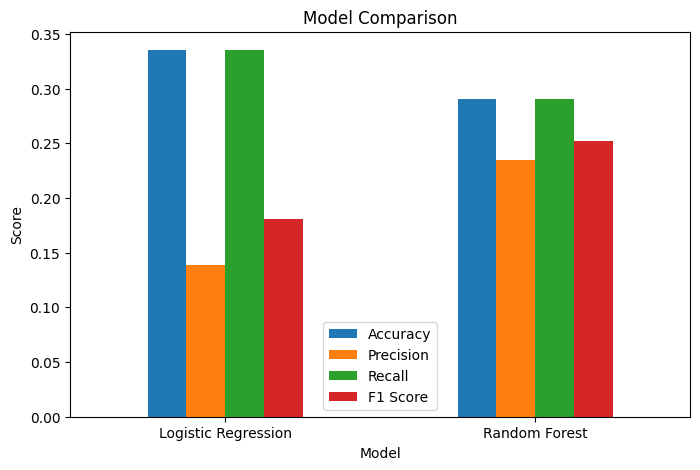

In [55]:
# Comparison Graph
results.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

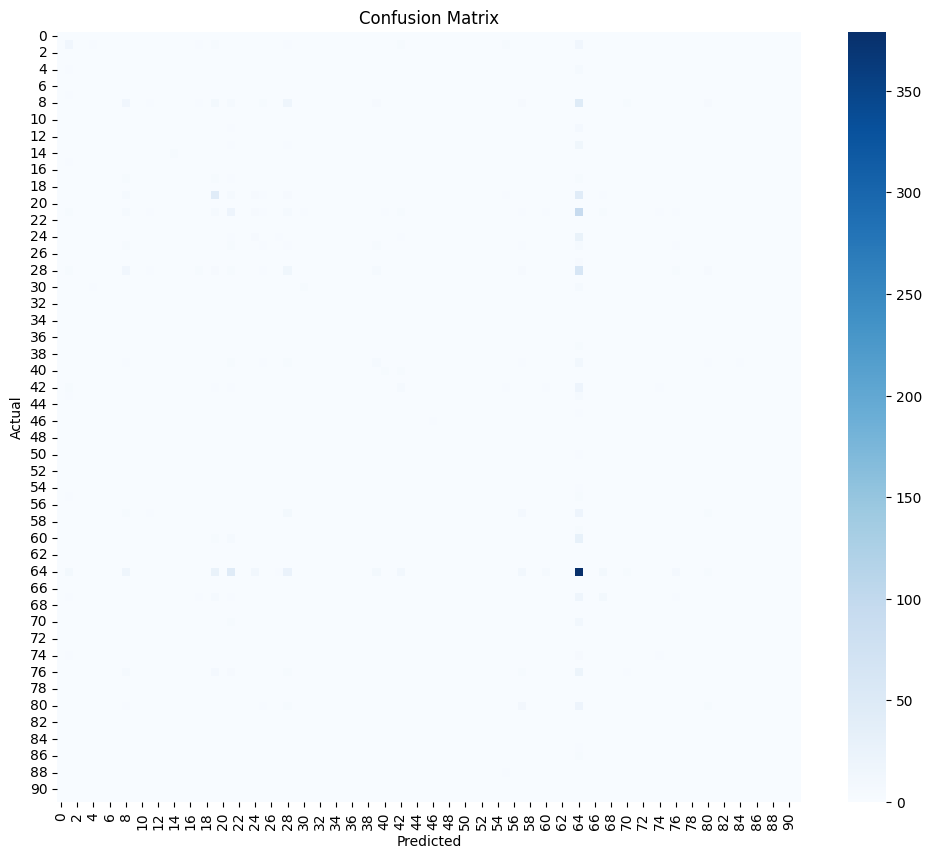

In [56]:
# Confusion Matrix (Random Forest)
cm = confusion_matrix(y_test,pred_rf)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [57]:
# Feature Importance
importance = pd.DataFrame({

"Feature":X.columns,

"Importance":rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

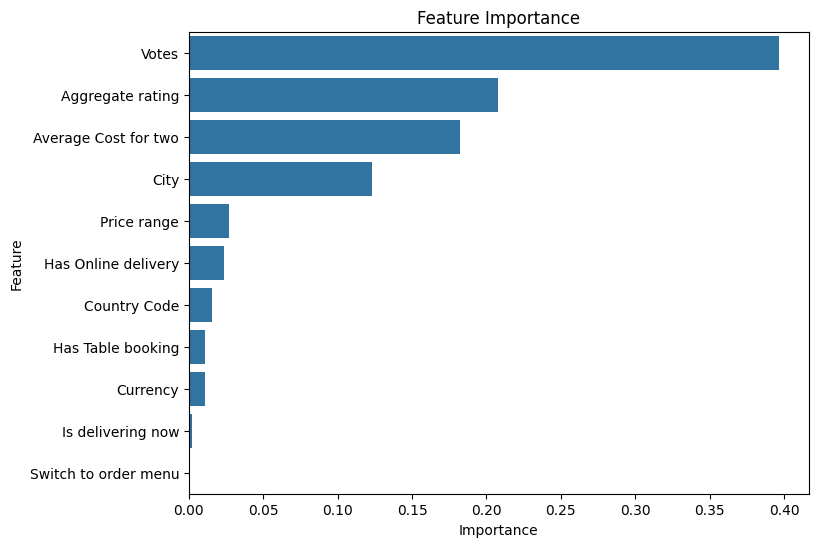

In [58]:
plt.figure(figsize=(8,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()

In [59]:
import pickle

pickle.dump(
    rf,
    open("Cuisine_Classifier.pkl","wb")
)

print("Model Saved Successfully")

Model Saved Successfully


In [60]:
model = pickle.load(
    open("Cuisine_Classifier.pkl","rb")
)

In [61]:
print("="*60)
print("Cuisine Classification Project Completed")
print("="*60)

print("\nBest Model : Random Forest")

print("\nAccuracy :",accuracy_score(y_test,pred_rf))

print("\nThe model successfully predicts restaurant cuisine using restaurant attributes.")

print("\nEvaluation Metrics Used:")
print("- Accuracy")
print("- Precision")
print("- Recall")
print("- F1 Score")

print("\nModel saved as Cuisine_Classifier.pkl")

Cuisine Classification Project Completed

Best Model : Random Forest

Accuracy : 0.2901364113326338

The model successfully predicts restaurant cuisine using restaurant attributes.

Evaluation Metrics Used:
- Accuracy
- Precision
- Recall
- F1 Score

Model saved as Cuisine_Classifier.pkl
